In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from copy import deepcopy as copy
import importlib
import phise

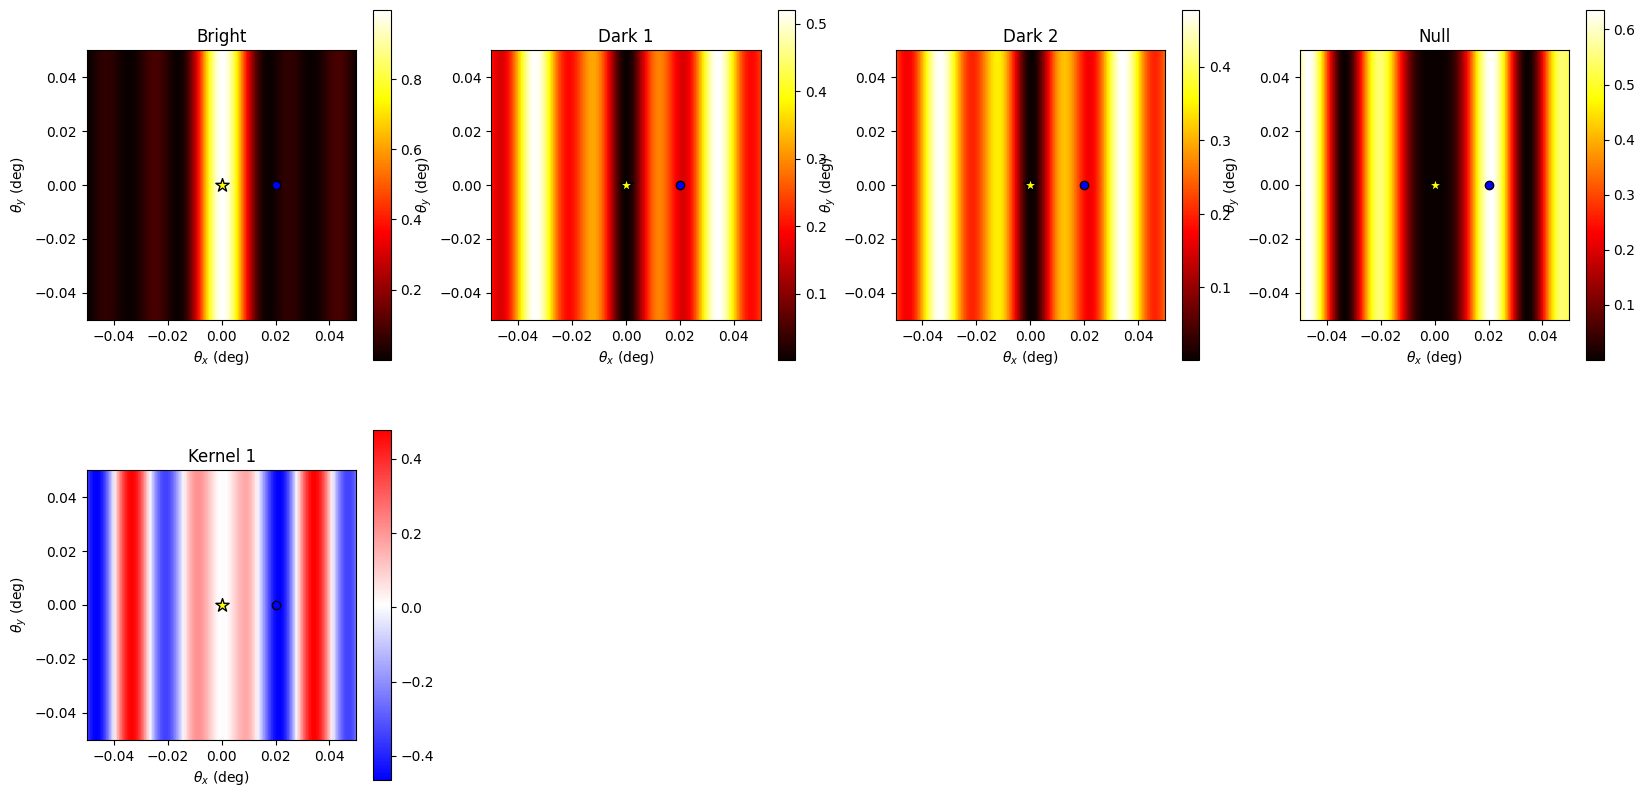


Tunable Laser Star throughputs:
----------
   Bright: 99.68%,   Dark 1: 0.13%,   Dark 2: 0.14%,   Null: 0.05%
   Kernel 1: 0.09%
Unnamed Companion throughputs:
----------
   Bright: 1.74%,   Dark 1: 17.07%,   Dark 2: 18.30%,   Null: 62.89%
   Kernel 1: -44.58%


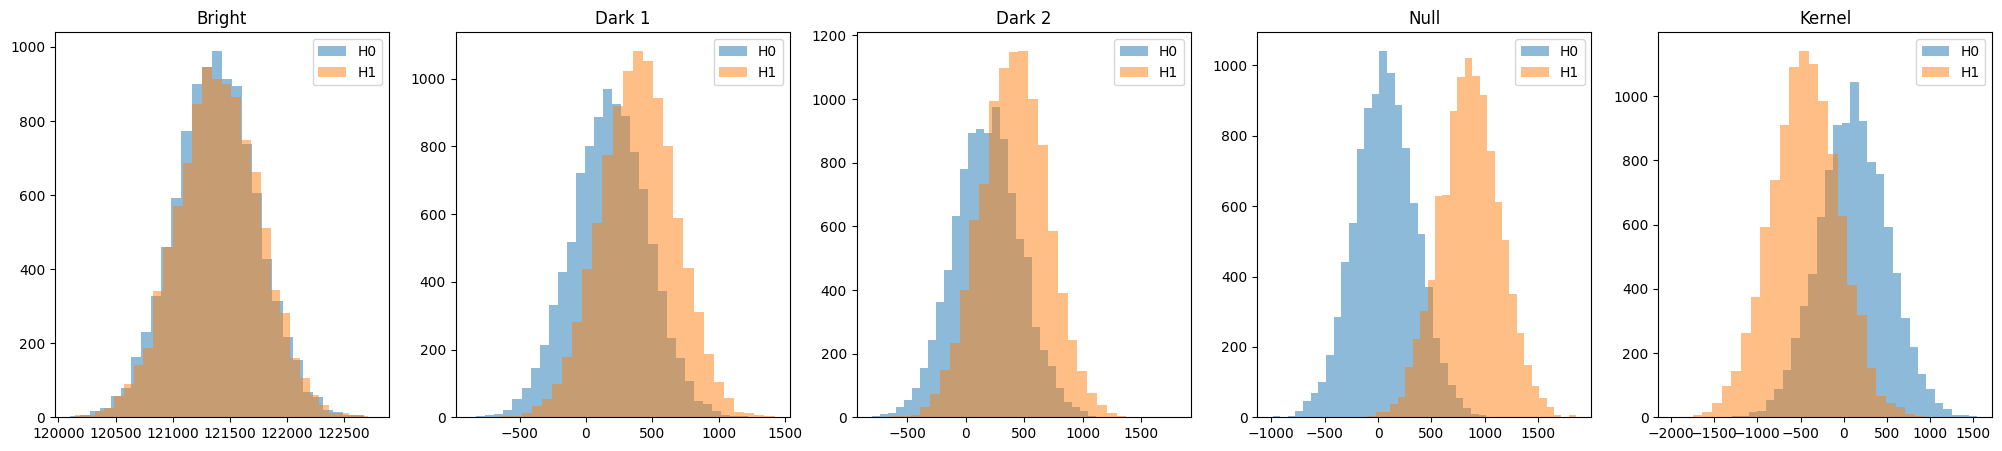

In [2]:
importlib.reload(phise)

ctx = phise.examples.contexts.get_PHOB()
ctx.interferometer.fov = 0.1 * u.deg
ctx.chip.calibrate()
ctx.Γ = 0 * u.nm # 1nm of upstream piston rms
ctx_h0 = copy(ctx)
ctx_h0.target.companions = []
ctx_h1 = copy(ctx)
ctx_h1.target.companions = [phise.Companion(1e-2, 0.02*u.deg, 0*u.deg)]

ctx_h1.plot_transmission_maps(N=100)

N = 10000

n_raw = ctx.chip.nb_raw_outputs
n_processed = ctx.chip.nb_processed_outputs

data_h0 = np.empty((n_raw + n_processed, N))
data_h1 = np.empty((n_raw + n_processed, N))

for i in range(N):
    h0_outs = ctx_h0.observe()
    h1_outs = ctx_h1.observe()
    data_h0[:n_raw, i] = h0_outs
    data_h1[:n_raw, i] = h1_outs
    data_h0[n_raw:, i] = ctx_h0.chip.process_outputs(h0_outs)
    data_h1[n_raw:, i] = ctx_h1.chip.process_outputs(h1_outs)

titles = ['Bright', 'Dark 1', 'Dark 2', 'Null', 'Kernel']
fig, axs = plt.subplots(1, n_raw + n_processed, figsize=((n_raw + n_processed) * 5, 5))
for i in range(n_raw + n_processed):
    axs[i].hist(data_h0[i, :], bins=30, alpha=0.5, label='H0')
    axs[i].hist(data_h1[i, :], bins=30, alpha=0.5, label='H1')
    axs[i].set_title(titles[i])
    axs[i].legend()

## Ajustement NSC réduit (3 paramètres) sur H0 et H1

On implémente une version réduite du **Null Self Calibration (NSC)** (Hanot et al. 2011), en réduisant le modèle de 6 à 3 paramètres pour éviter la dégénérescence.

Pour chaque sortie de null, l'estimateur normalisé est :

$$n = \frac{I_{\mathrm{null}}}{I_{\mathrm{bright}}}$$

### Modèle forward réduit

Les termes d'erreur de phase ($\Delta\phi$) et de mismatch d'intensité ($\delta I$) sont **parfaitement dégénérés** dans le terme quadratique lorsque $\mu_{\delta I} = 0$ — ils jouent exactement le même rôle dans la distribution. De plus, après normalisation par $I_\mathrm{bright}$, le facteur $\sigma_\mathrm{ir}$ est redondant. On les fusionne donc en un seul terme :

$$n = N_a + \frac{1}{4}\left(\xi_1^2 + \xi_2^2\right) + \epsilon_\mathrm{bias}$$

avec $\xi_1, \xi_2 \sim \mathcal{N}(0, \sigma_\mathrm{inst})$ et $\epsilon_\mathrm{bias} \sim \mathcal{N}(0, \sigma_\mathrm{bias})$.

Le terme quadratique $\frac{1}{4}(\xi_1^2 + \xi_2^2) = \frac{\sigma_\mathrm{inst}^2}{4} \cdot \chi^2(2)$ est **asymétrique vers la droite**, ce qui est cohérent avec les distributions observées.

### Paramètres (3 au lieu de 6)

| Paramètre | Signification |
|-----------|---------------|
| $N_a$ | Null astrophysique recherché |
| $\sigma_\mathrm{inst}$ | Perturbations instrumentales (phase + intensité fusionnées) |
| $\sigma_\mathrm{bias}$ | Bruit détecteur additif |

On ajuste sur les sorties null-like uniquement : **Dark 1**, **Dark 2**, **Null**.


=== H0 ===
Dark 1 -> Na=-2.714e-03, sigma_inst=9.180e-02 (moment~6.853e-02), sigma_bias=4.696e-04, sigma_bias_max=4.696e-04, success=True
Dark 2 -> Na=-2.597e-03, sigma_inst=9.051e-02 (moment~6.826e-02), sigma_bias=4.660e-04, sigma_bias_max=4.660e-04, success=True
Null -> Na=-3.554e-03, sigma_inst=9.056e-02 (moment~6.815e-02), sigma_bias=4.644e-04, sigma_bias_max=4.644e-04, success=True

=== H1 ===
Dark 1 -> Na=-8.881e-04, sigma_inst=9.109e-02 (moment~6.803e-02), sigma_bias=4.628e-04, sigma_bias_max=4.628e-04, success=True
Dark 2 -> Na=-7.323e-04, sigma_inst=9.086e-02 (moment~6.828e-02), sigma_bias=4.662e-04, sigma_bias_max=4.662e-04, success=True
Null -> Na=2.988e-03, sigma_inst=9.057e-02 (moment~6.772e-02), sigma_bias=4.587e-04, sigma_bias_max=4.587e-04, success=True


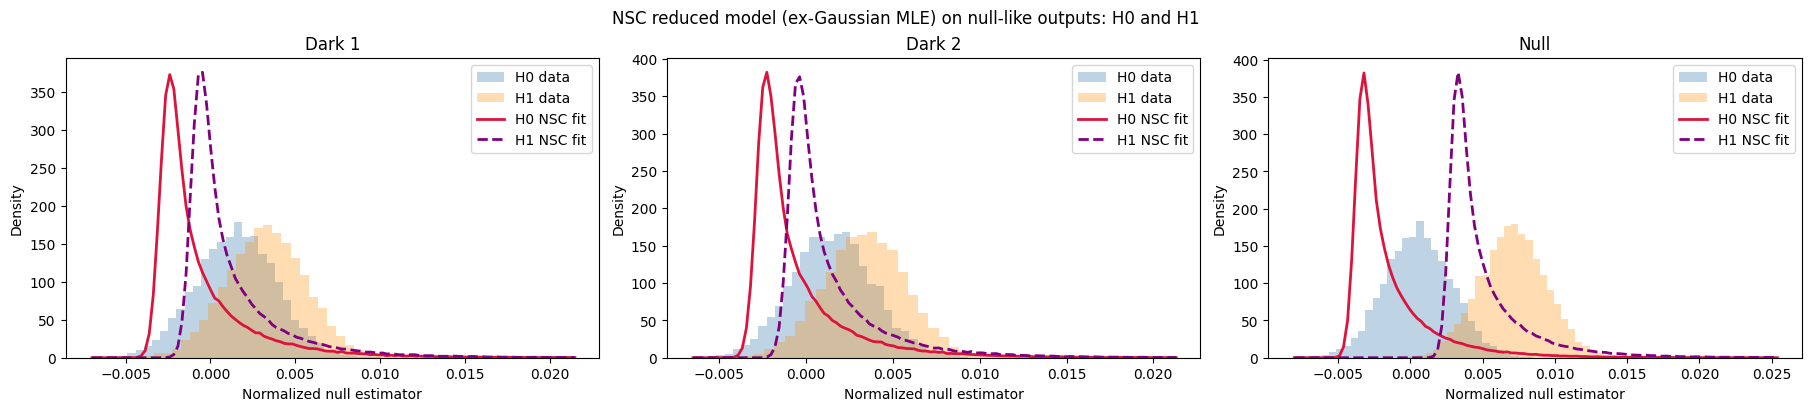

Estimated astrophysical null (Na^) from H0/Null = 0.000e+00
Estimated astrophysical null (Na^) from H1/Null = 2.988e-03


In [3]:
import scipy.stats as stats
from scipy.stats import exponnorm
from scipy.optimize import minimize

def nsc_forward_sample(size, na, sigma_inst, sigma_bias, rng):
    """Generate samples from the NSC forward model."""
    inst = rng.normal(loc=0.0, scale=sigma_inst, size=size)
    bias = rng.normal(loc=0.0, scale=sigma_bias, size=size)
    return na + 0.25 * inst**2 + bias


def fit_nsc_classic(
    null_sample,
    sigma_bias_max=None,
    lambda_bias=0.10,
):
    """Fit NSC parameters (Na, sigma_inst, sigma_bias) by ex-Gaussian MLE.

    Using the analytical ex-Gaussian likelihood avoids Monte-Carlo noise and
    strongly reduces pathological minima where sigma_inst collapses.
    """
    x = np.asarray(null_sample, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 20:
        raise ValueError("Null sample must contain at least 20 finite points.")

    x_mean = float(np.mean(x))
    x_med = float(np.median(x))
    x_std = max(float(np.std(x)), 1e-12)

    if sigma_bias_max is None:
        sigma_bias_max = max(1e-9, 0.25 * x_std)
    sigma_bias_max = max(1e-9, float(sigma_bias_max))

    # Moment scale: std(q) = 0.5 * sigma_inst^2 => sigma_inst ~ sqrt(2 * std).
    sigma_inst_moment = max(np.sqrt(2.0 * x_std), 1e-6)

    sigma_inst_min = 1e-6
    sigma_inst_max = max(20.0 * sigma_inst_moment, 1.0)

    # Allow slight negative Na in optimization to avoid compensation bias.
    na_min = float(np.min(x) - x_std)
    na_max = float(np.max(x) + x_std)

    # Initial guesses from ex-Gaussian moments.
    tau_guess = max(x_mean - x_med, 1e-9)
    sigma_inst_guess = max(np.sqrt(2.0 * tau_guess), 0.5 * sigma_inst_moment)
    sigma_bias_guess = np.sqrt(max(x_std**2 - tau_guess**2, 1e-12))
    sigma_bias_guess = float(np.clip(sigma_bias_guess, 1e-9, sigma_bias_max))

    # Two starts to avoid local minima.
    starts = [
        np.array([
            np.clip(x_med, na_min, na_max),
            np.log(np.clip(sigma_inst_guess, sigma_inst_min, sigma_inst_max)),
            np.log(sigma_bias_guess),
        ]),
        np.array([
            np.clip(x_med - 0.2 * x_std, na_min, na_max),
            np.log(np.clip(sigma_inst_moment, sigma_inst_min, sigma_inst_max)),
            np.log(np.clip(0.05 * x_std, 1e-9, sigma_bias_max)),
        ]),
    ]

    bounds = [
        (na_min, na_max),
        (np.log(sigma_inst_min), np.log(sigma_inst_max)),
        (np.log(1e-9), np.log(sigma_bias_max)),
    ]

    def objective(params):
        na = float(params[0])
        sigma_inst = float(np.exp(params[1]))
        sigma_bias = float(np.exp(params[2]))

        tau = 0.5 * sigma_inst**2
        scale = max(sigma_bias, 1e-12)
        k_shape = tau / scale

        logpdf = exponnorm.logpdf(x, K=k_shape, loc=na, scale=scale)
        if not np.all(np.isfinite(logpdf)):
            return np.inf

        nll = -float(np.mean(logpdf))

        # Weak prior to keep additive bias small unless required by data.
        j_prior = (sigma_bias / sigma_bias_max) ** 2

        return nll + lambda_bias * j_prior

    best = None
    for p0 in starts:
        res = minimize(objective, p0, method="L-BFGS-B", bounds=bounds)
        if best is None or res.fun < best.fun:
            best = res

    na = float(best.x[0])
    sigma_inst = float(np.exp(best.x[1]))
    sigma_bias = float(np.exp(best.x[2]))

    return {
        "na": na,
        "sigma_inst": sigma_inst,
        "sigma_bias": sigma_bias,
        "sigma_inst_moment": sigma_inst_moment,
        "sigma_bias_max": sigma_bias_max,
        "success": bool(best.success),
        "message": best.message,
        "objective": float(best.fun),
    }


# We fit only null-like outputs (Dark1, Dark2, Null).
fit_indices = [idx for idx in [1, 2, 3] if idx < data_h0.shape[0]]


def build_normalized_nulls(data):
    """Normalize null-like outputs by the bright output for one hypothesis set."""
    bright = data[0, :]
    valid = np.isfinite(bright) & (bright > 0)
    return {idx: (data[idx, valid] / bright[valid]) for idx in fit_indices}


def fit_one_hypothesis(null_estimators, sigma_bias_factor=0.20):
    """Fit NSC parameters output-by-output for one hypothesis (H0 or H1)."""
    fits = {}
    for idx in fit_indices:
        x = np.asarray(null_estimators[idx], dtype=float)
        x_std = max(np.std(x), 1e-12)
        sb_max = max(1e-9, sigma_bias_factor * x_std)
        fits[idx] = fit_nsc_classic(
            x,
            sigma_bias_max=sb_max,
            lambda_bias=0.10,
        )
    return fits


nulls_h0 = build_normalized_nulls(data_h0)
nulls_h1 = build_normalized_nulls(data_h1)

fits_h0 = fit_one_hypothesis(nulls_h0, sigma_bias_factor=0.20)
fits_h1 = fit_one_hypothesis(nulls_h1, sigma_bias_factor=0.20)

print("=== H0 ===")
for idx in fit_indices:
    p = fits_h0[idx]
    print(
        f"{titles[idx]} -> Na={p['na']:.3e}, "
        f"sigma_inst={p['sigma_inst']:.3e} (moment~{p['sigma_inst_moment']:.3e}), "
        f"sigma_bias={p['sigma_bias']:.3e}, "
        f"sigma_bias_max={p['sigma_bias_max']:.3e}, success={p['success']}"
    )

print("\n=== H1 ===")
for idx in fit_indices:
    p = fits_h1[idx]
    print(
        f"{titles[idx]} -> Na={p['na']:.3e}, "
        f"sigma_inst={p['sigma_inst']:.3e} (moment~{p['sigma_inst_moment']:.3e}), "
        f"sigma_bias={p['sigma_bias']:.3e}, "
        f"sigma_bias_max={p['sigma_bias_max']:.3e}, success={p['success']}"
    )


# Plot both hypotheses with their NSC fits on the same axes.
fig, axes = plt.subplots(1, len(fit_indices), figsize=(6 * len(fit_indices), 4), constrained_layout=True)
if len(fit_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, fit_indices):
    sample_h0 = nulls_h0[idx]
    sample_h1 = nulls_h1[idx]
    p0 = fits_h0[idx]
    p1 = fits_h1[idx]

    ax.hist(sample_h0, bins=35, density=True, alpha=0.35, color="steelblue", label="H0 data")
    ax.hist(sample_h1, bins=35, density=True, alpha=0.30, color="darkorange", label="H1 data")

    rng0 = np.random.default_rng(1000 + idx)
    sim0 = nsc_forward_sample(
        size=200000,
        na=p0["na"],
        sigma_inst=p0["sigma_inst"],
        sigma_bias=p0["sigma_bias"],
        rng=rng0,
    )

    rng1 = np.random.default_rng(2000 + idx)
    sim1 = nsc_forward_sample(
        size=200000,
        na=p1["na"],
        sigma_inst=p1["sigma_inst"],
        sigma_bias=p1["sigma_bias"],
        rng=rng1,
    )

    x_min = min(np.min(sample_h0), np.min(sample_h1), np.percentile(sim0, 0.1), np.percentile(sim1, 0.1))
    x_max = max(np.max(sample_h0), np.max(sample_h1), np.percentile(sim0, 99.9), np.percentile(sim1, 99.9))
    bins = np.linspace(x_min, x_max, 120)

    hist0, edges = np.histogram(sim0, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.plot(centers, hist0, color="crimson", lw=2, label="H0 NSC fit")

    hist1, edges = np.histogram(sim1, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.plot(centers, hist1, color="purple", lw=2, ls="--", label="H1 NSC fit")

    ax.set_title(titles[idx])
    ax.set_xlabel("Normalized null estimator")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("NSC reduced model (ex-Gaussian MLE) on null-like outputs: H0 and H1")
plt.show()


# Report Na^ from the dedicated Null output (index 3) for both hypotheses.
if 3 in fits_h0:
    na_hat_h0 = max(0.0, fits_h0[3]["na"])
    print(f"Estimated astrophysical null (Na^) from H0/{titles[3]} = {na_hat_h0:.3e}")
else:
    print("H0: index 3 ('Null') not available in current data.")

if 3 in fits_h1:
    na_hat_h1 = max(0.0, fits_h1[3]["na"])
    print(f"Estimated astrophysical null (Na^) from H1/{titles[3]} = {na_hat_h1:.3e}")
else:
    print("H1: index 3 ('Null') not available in current data.")


In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output


def _fit_map_for_hypothesis(hypothesis):
    return fits_h0 if hypothesis == "H0" else fits_h1


def _nulls_map_for_hypothesis(hypothesis):
    return nulls_h0 if hypothesis == "H0" else nulls_h1


def _available_indices(hypothesis):
    fit_map = _fit_map_for_hypothesis(hypothesis)
    return sorted(fit_map.keys())


def _default_params(hypothesis, output_idx):
    fit_map = _fit_map_for_hypothesis(hypothesis)
    p = fit_map[output_idx]
    return p["na"], p["sigma_inst"], p["sigma_bias"]


def _slider_step(v):
    return max(v / 100.0, 1e-9)


hypothesis_dd = widgets.Dropdown(
    options=[("H0", "H0"), ("H1", "H1")],
    value="H0",
    description="Hypothesis:",
)

initial_indices = _available_indices(hypothesis_dd.value)
output_dd = widgets.Dropdown(
    options=[(titles[idx], idx) for idx in initial_indices],
    value=initial_indices[0],
    description="Output:",
)

na0, si0, sb0 = _default_params(hypothesis_dd.value, output_dd.value)

na_slider = widgets.FloatSlider(
    description="Na",
    value=na0,
    min=0,
    max=max(na0 * 3.0, na0 + 5.0 * max(si0, sb0, 1e-6)),
    step=_slider_step(max(na0, 1e-8)),
    readout_format=".2e",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

sigma_inst_slider = widgets.FloatSlider(
    description="sigma_inst",
    value=si0,
    min=1e-9,
    max=1e0,
    step=_slider_step(max(si0, 1e-8)),
    readout_format=".2e",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

sigma_bias_slider = widgets.FloatSlider(
    description="sigma_bias",
    value=sb0,
    min=1e-9,
    max=1e0,
    step=_slider_step(max(sb0, 1e-8)),
    readout_format=".2e",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

n_model_slider = widgets.IntSlider(
    description="N model",
    value=150000,
    min=20000,
    max=500000,
    step=10000,
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

reset_button = widgets.Button(description="Reset to fitted params", button_style="info")
out = widgets.Output()


def _update_output_options(*_):
    indices = _available_indices(hypothesis_dd.value)
    output_dd.options = [(titles[idx], idx) for idx in indices]
    if output_dd.value not in indices:
        output_dd.value = indices[0]


def _set_sliders_to_fit(*_):
    na_fit, si_fit, sb_fit = _default_params(hypothesis_dd.value, output_dd.value)

    na_slider.min = max(0.0, na_fit * 0.1)
    na_slider.max = max(na_fit * 3.0, na_fit + 5.0 * max(si_fit, sb_fit, 1e-6))
    na_slider.step = _slider_step(max(na_fit, 1e-8))
    na_slider.value = na_fit

    sigma_inst_slider.max = 1e0
    sigma_inst_slider.step = _slider_step(max(si_fit, 1e-8))
    sigma_inst_slider.value = si_fit

    sigma_bias_slider.max = 1e0
    sigma_bias_slider.step = _slider_step(max(sb_fit, 1e-8))
    sigma_bias_slider.value = sb_fit


def _draw(*_):
    hypothesis = hypothesis_dd.value
    idx = output_dd.value
    na = na_slider.value
    sigma_inst = sigma_inst_slider.value
    sigma_bias = sigma_bias_slider.value
    n_model = n_model_slider.value

    sample = _nulls_map_for_hypothesis(hypothesis)[idx]

    rng = np.random.default_rng(4242)
    sim = nsc_forward_sample(
        size=n_model,
        na=na,
        sigma_inst=sigma_inst,
        sigma_bias=sigma_bias,
        rng=rng,
    )

    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))

        ax.hist(sample, bins=40, density=True, alpha=0.35, color="steelblue", label=f"{hypothesis} data")

        x_min = min(np.min(sample), np.percentile(sim, 0.1))
        x_max = max(np.max(sample), np.percentile(sim, 99.9))
        bins = np.linspace(x_min, x_max, 120)
        hist, edges = np.histogram(sim, bins=bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centers, hist, color="crimson", lw=2, label="NSC model")

        ax.set_title(f"{titles[idx]} - {hypothesis}")
        ax.set_xlabel("Normalized null estimator")
        ax.set_ylabel("Density")
        ax.legend()
        plt.show()


hypothesis_dd.observe(_update_output_options, names="value")
hypothesis_dd.observe(_set_sliders_to_fit, names="value")
output_dd.observe(_set_sliders_to_fit, names="value")

for w in [na_slider, sigma_inst_slider, sigma_bias_slider, n_model_slider, hypothesis_dd, output_dd]:
    w.observe(_draw, names="value")

reset_button.on_click(_set_sliders_to_fit)

controls = widgets.VBox([
    widgets.HTML("<h3>NSC interactive overlay</h3>"),
    widgets.HBox([hypothesis_dd, output_dd]),
    na_slider,
    sigma_inst_slider,
    sigma_bias_slider,
    n_model_slider,
    reset_button,
])

display(controls, out)

_set_sliders_to_fit()
_draw()


Output()

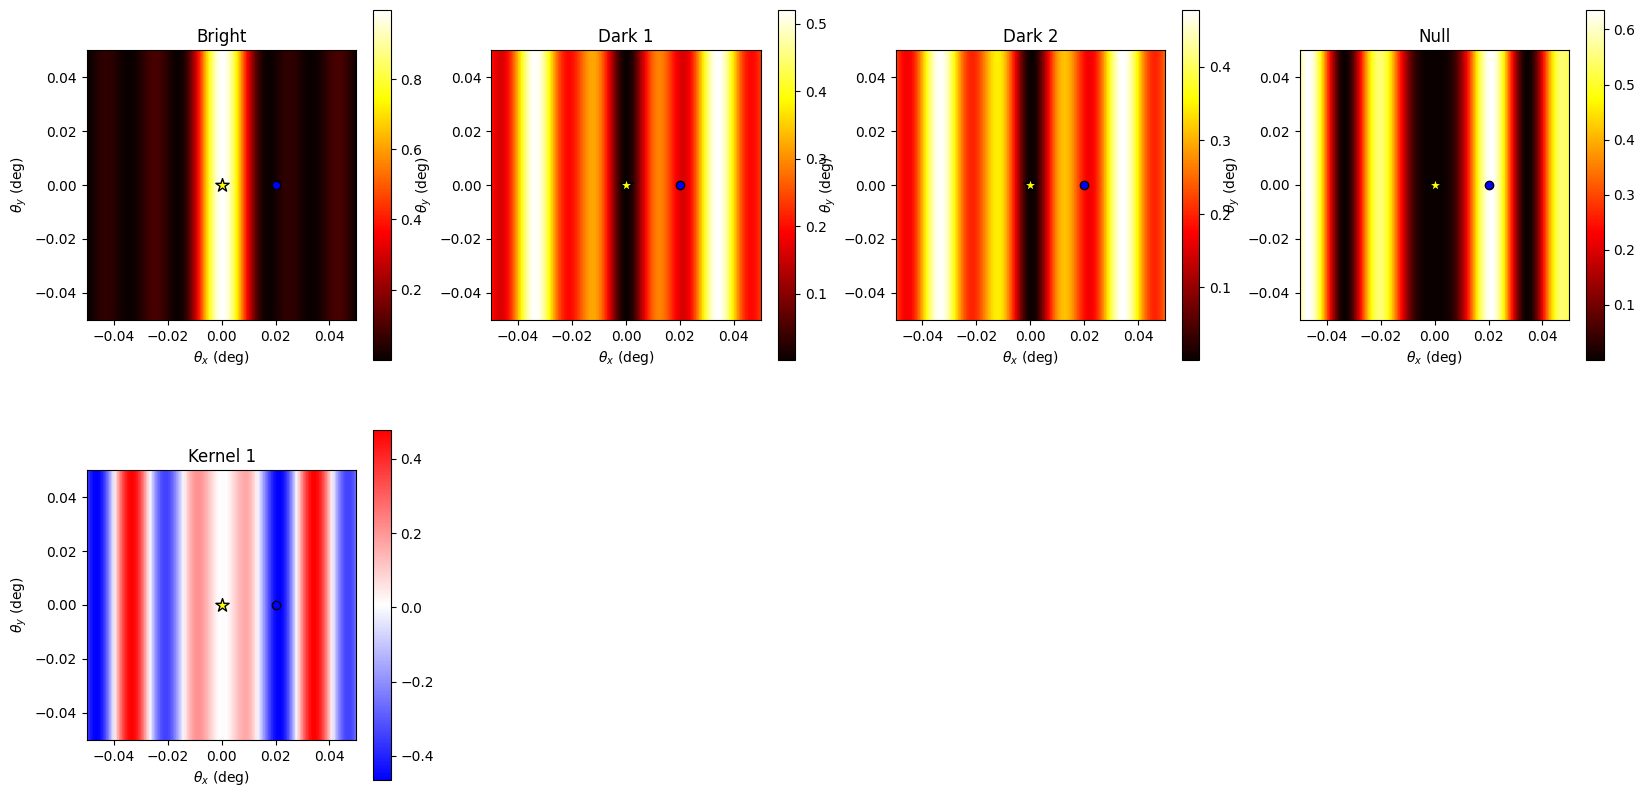


Tunable Laser Star throughputs:
----------
   Bright: 99.68%,   Dark 1: 0.13%,   Dark 2: 0.14%,   Null: 0.05%
   Kernel 1: 0.09%
Unnamed Companion throughputs:
----------
   Bright: 1.74%,   Dark 1: 17.07%,   Dark 2: 18.30%,   Null: 62.89%
   Kernel 1: -44.58%
Target "Tunable Laser"
  f: 1.00e-05 W / (nm m2)
  δ: -9.00e+01 deg
  Companions:
    Companion "Unnamed Companion"
      Contrast: 0.00
      Angular separation: 0.02 deg
      Parallactic angle: 0.00 deg


In [ ]:
import os

# roc_ctx_h1 = phise.examples.contexts.get_VLTI()
# roc_ctx_h1.chip = copy(ctx_h1.chip)
roc_ctx_h1 = copy(ctx_h1)
roc_ctx_h1.target.companions[0].c = 1e-4
roc_ctx_h1.plot_transmission_maps(N=100)
print(roc_ctx_h1.target)

roc_ctx_h0 = copy(roc_ctx_h1)
roc_ctx_h0.target.companions = []

force_generate = True
if os.path.exists("roc_data.npz") and not force_generate:
    loaded = np.load("roc_data.npz")
    T0 = loaded["T0"]
    T1 = loaded["T1"]
else:
    T0, T1 = phise.roc.generate_data(roc_ctx_h1, roc_ctx_h0, nmc=1000, size=1000, progress_callback=lambda p: print(f"Progress: {p:.1%}", end='\r'), randomize_position=False)
    np.savez("roc_data.npz", T0=T0, T1=T1)

phise.roc.plot_roc_curves(T0[3], T1[3])